# Initial Work to Digitize Calorimeter Hits

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("../")
# from utils import load_root_file, load_hepmc_event
from edm4hep_utils import build_calo_df, build_particle_df, build_tracker_df, load_edm4hep_file
from clustering_metrics import evaluate_clustering, plot_clustering_metrics

from edm4hep_utils import pixel_readouts, strip_readouts
all_tracker_readouts = pixel_readouts + strip_readouts

## Roadmap

1. Load in ecal barrel calorimeter hits
2. Structure a digitisation function

# Loading

In [2]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pion_10GeV"
event_num = 0

## 1. Load in edm4hep file

In [3]:
low_threshold_edm4hep_file = f"{base_dir}/single_run_test_low_threshold/edm4hep.root"

low_threshold_event = load_edm4hep_file(low_threshold_edm4hep_file, event_num=event_num)

In [4]:
low_threshold_event.keys()

dict_keys(['tracker_df', 'calo_hits_df', 'calo_contrib_df', 'particles_df', 'parents_df', 'daughters_df'])

In [5]:
low_tracker_df = low_threshold_event["tracker_df"]
low_tracker_df.columns

Index(['cellID', 'EDep', 'time', 'pathLength', 'quality', 'x', 'y', 'z', 'px',
       'py', 'pz', 'particle_id', 'r', 'R', 'phi', 'theta', 'eta', 'pt',
       'detector'],
      dtype='object')

In [6]:
low_parents_df = low_threshold_event["parents_df"]

low_daughters_df = low_threshold_event["daughters_df"]

low_particles_df = low_threshold_event["particles_df"]

# Create a column from the index
low_particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi'],
      dtype='object')

In [7]:
hits_df = low_threshold_event["calo_hits_df"]
hits_df.columns

Index(['cellID', 'energy', 'x', 'y', 'z', 'contribution_begin',
       'contribution_end', 'r', 'R', 'phi', 'theta', 'eta', 'detector'],
      dtype='object')

In [8]:
contrib_df = low_threshold_event["calo_contrib_df"]
contrib_df.columns


Index(['PDG', 'energy', 'time', 'step_x', 'step_y', 'step_z', 'particle_id',
       'x', 'y', 'z', 'detector'],
      dtype='object')

## Full Calo Digitisation

In [9]:
from calorimeter_digitisation import digitise_event

# Configure the digitizer
ecal_config = {
    "ehEnergy": 3.6e-9,  # 3.6 eV in GeV
}

hcal_config = {
    "hcal_PPD_pe_per_mip": 10,  # Photoelectrons per MIP
    "hcal_PPD_n_pixels": 400,   # Number of pixels in SiPM
    "calibHcalMip": 1.0e-4,     # MIP calibration factor
}

digi_ecal, digi_hcal = digitise_event(hits_df, contrib_df, ecal_config, hcal_config)

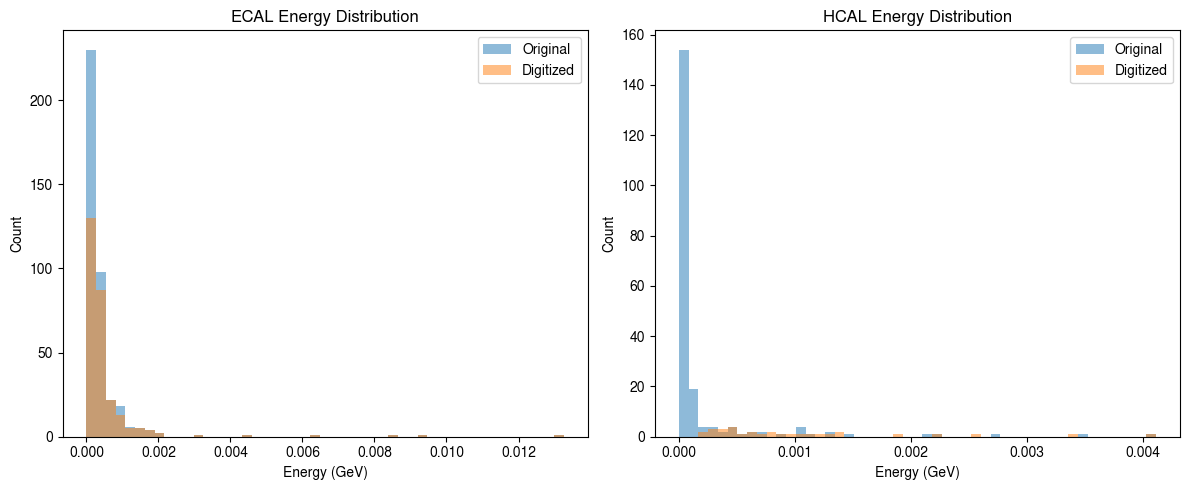

ECAL Statistics:
Original hits: 391
Digitized hits: 274
Original energy sum: 0.165672 GeV
Digitized energy sum: 0.151770 GeV

HCAL Statistics:
Original hits: 206
Digitized hits: 31
Original energy sum: 0.036366 GeV
Digitized energy sum: 0.031811 GeV


In [10]:
# Compare original and digitized energy distributions
plt.figure(figsize=(12, 5))

# ECAL energy comparison
plt.subplot(1, 2, 1)
ecal_hits = hits_df[hits_df['detector'].isin(['ECalBarrelCollection', 'ECalEndcapCollection'])]
# Define common bins for ECAL
ecal_min = min(ecal_hits['energy'].min(), digi_ecal['energy'].min())
ecal_max = max(ecal_hits['energy'].max(), digi_ecal['energy'].max())
ecal_bins = np.linspace(ecal_min, ecal_max, 50)
# Plot with common bins
plt.hist(ecal_hits['energy'], bins=ecal_bins, alpha=0.5, label='Original')
plt.hist(digi_ecal['energy'], bins=ecal_bins, alpha=0.5, label='Digitized')
plt.xlabel('Energy (GeV)')
plt.ylabel('Count')
plt.title('ECAL Energy Distribution')
plt.legend()

# HCAL energy comparison
plt.subplot(1, 2, 2)
hcal_hits = hits_df[hits_df['detector'].isin(['HCalBarrelCollection', 'HCalEndcapCollection'])]
# Define common bins for HCAL
hcal_min = min(hcal_hits['energy'].min(), digi_hcal['energy'].min())
hcal_max = max(hcal_hits['energy'].max(), digi_hcal['energy'].max())
hcal_bins = np.linspace(hcal_min, hcal_max, 50)
# Plot with common bins
plt.hist(hcal_hits['energy'], bins=hcal_bins, alpha=0.5, label='Original')
plt.hist(digi_hcal['energy'], bins=hcal_bins, alpha=0.5, label='Digitized')
plt.xlabel('Energy (GeV)')
plt.ylabel('Count')
plt.title('HCAL Energy Distribution')
plt.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("ECAL Statistics:")
print(f"Original hits: {len(ecal_hits)}")
print(f"Digitized hits: {len(digi_ecal)}")
print(f"Original energy sum: {ecal_hits['energy'].sum():.6f} GeV")
print(f"Digitized energy sum: {digi_ecal['energy'].sum():.6f} GeV")

print("\nHCAL Statistics:")
print(f"Original hits: {len(hcal_hits)}")
print(f"Digitized hits: {len(digi_hcal)}")
print(f"Original energy sum: {hcal_hits['energy'].sum():.6f} GeV")
print(f"Digitized energy sum: {digi_hcal['energy'].sum():.6f} GeV")

## Validation

### Energy Distribution

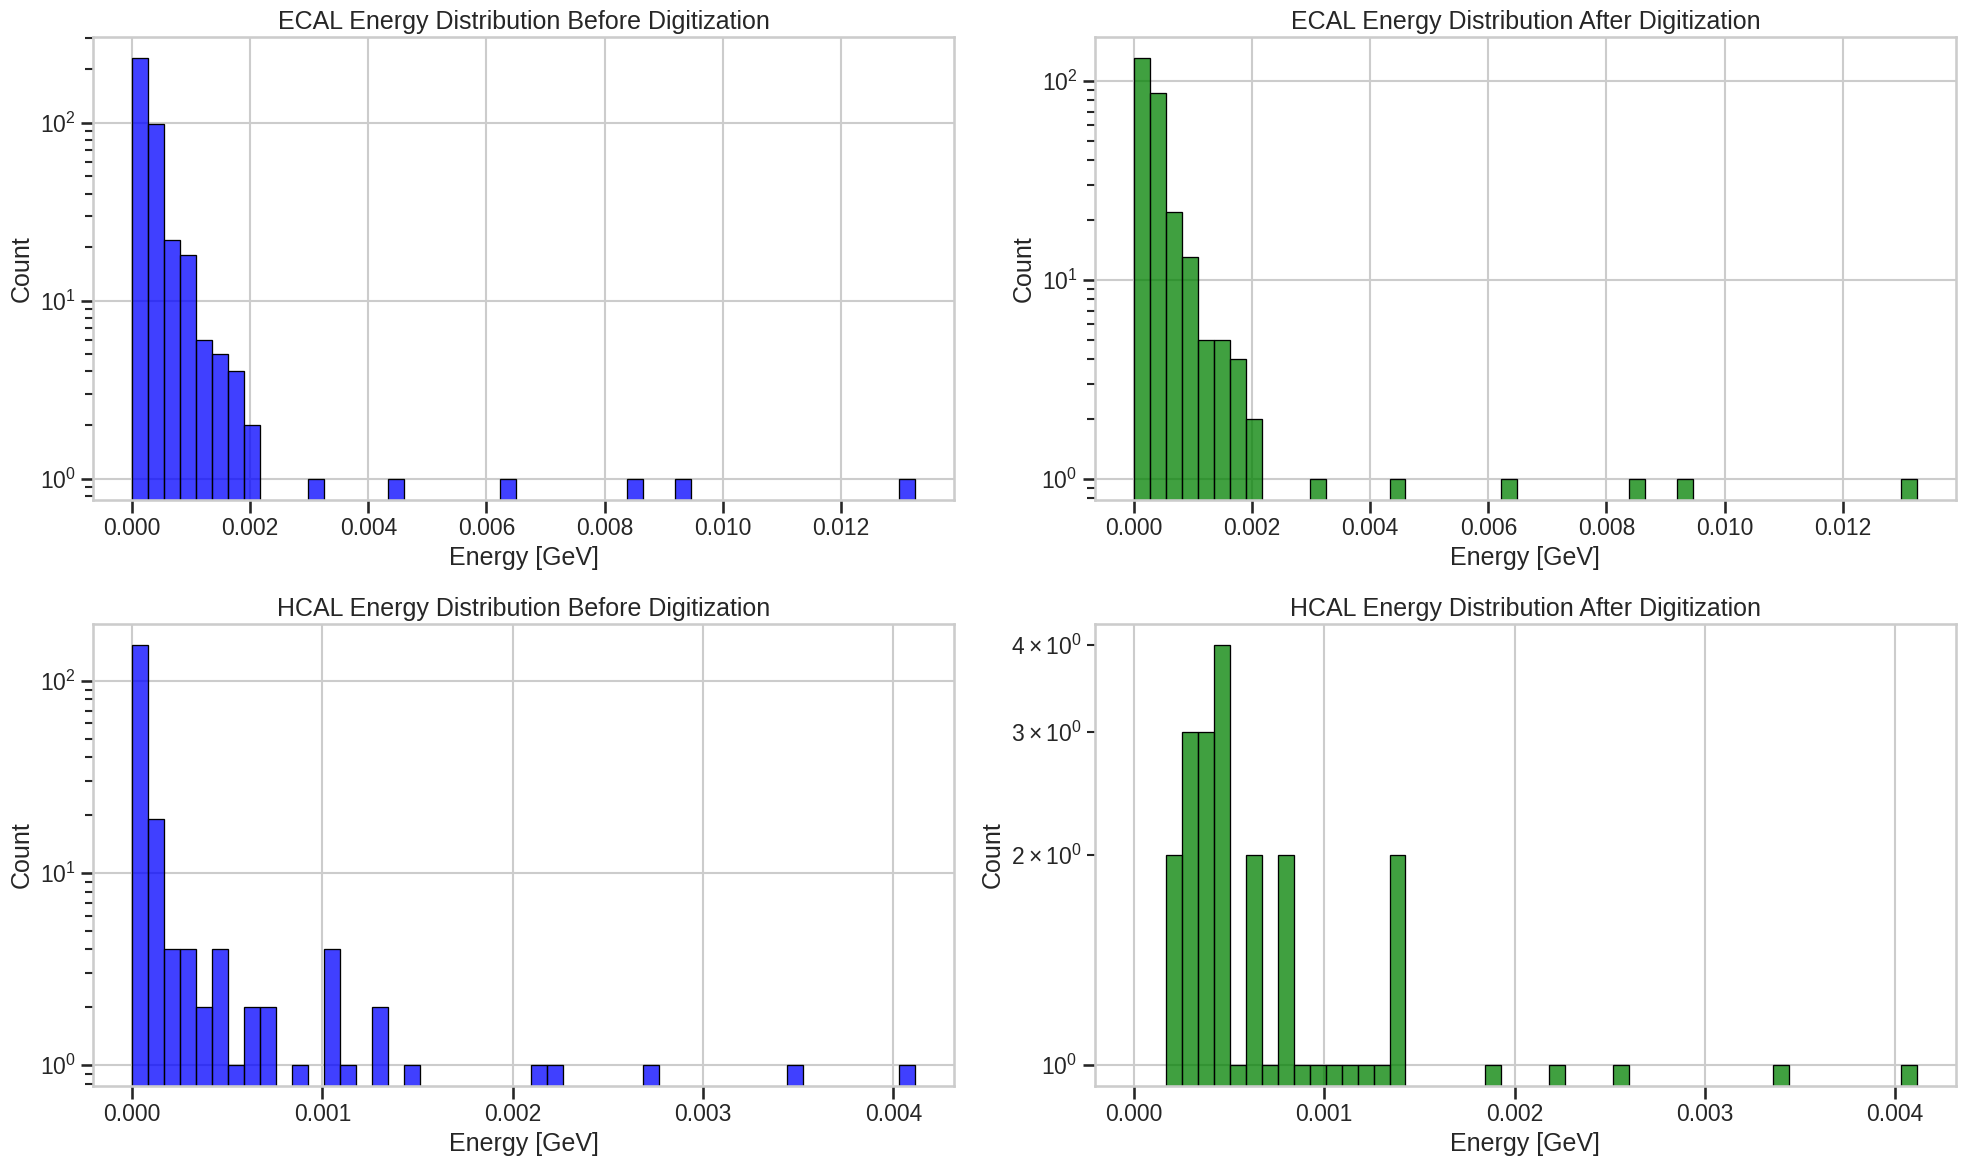

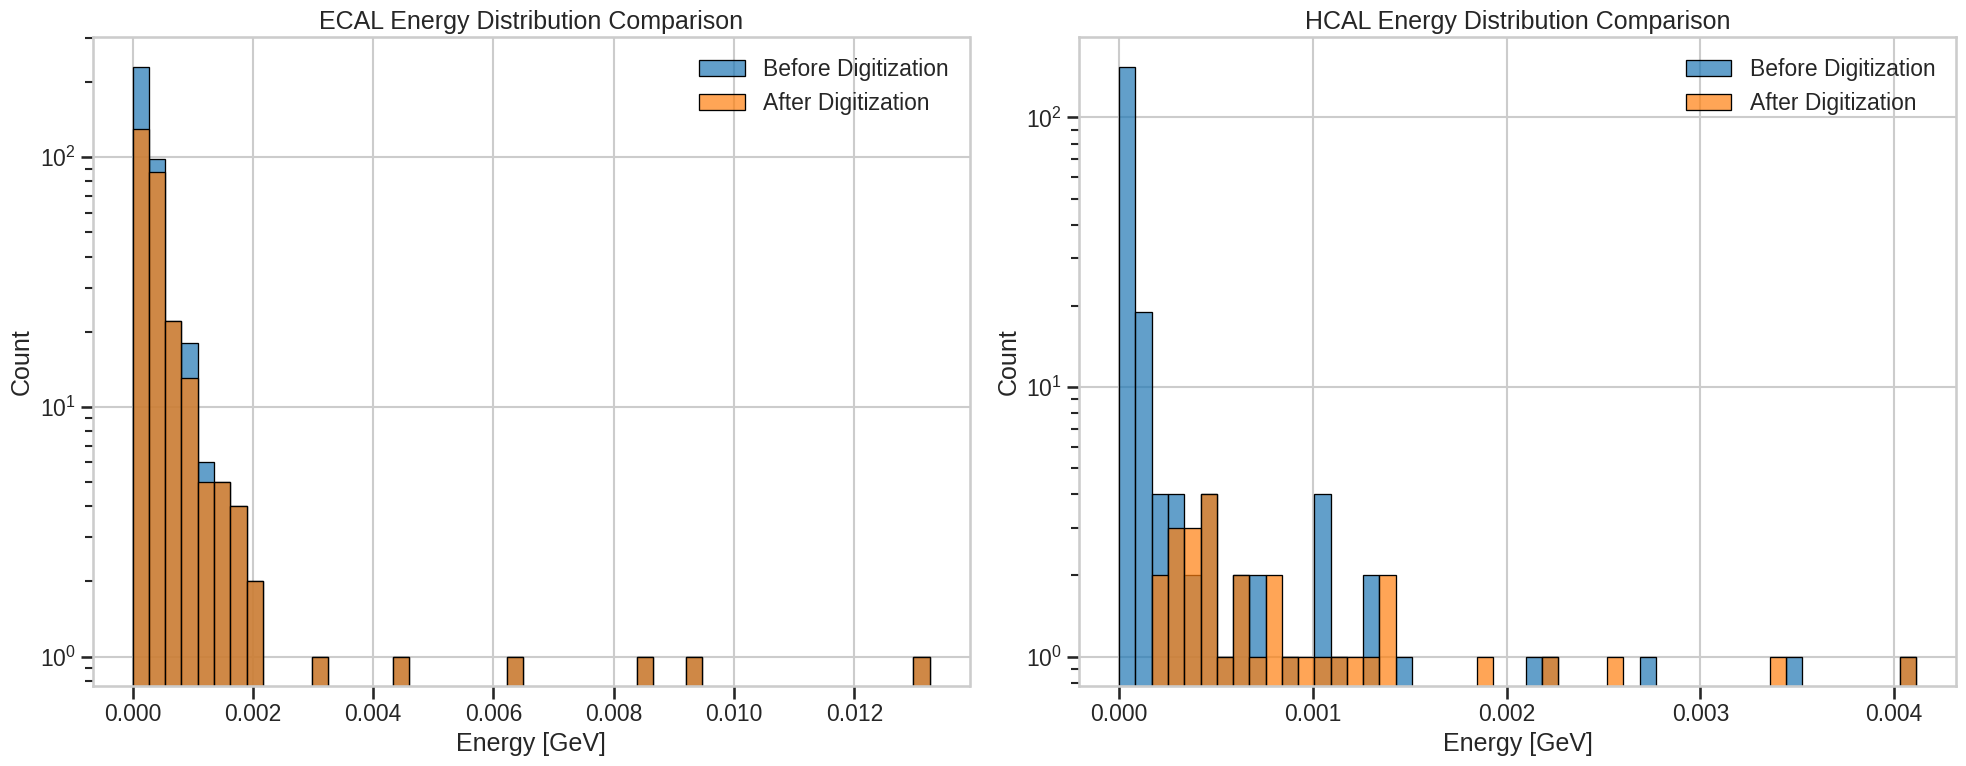

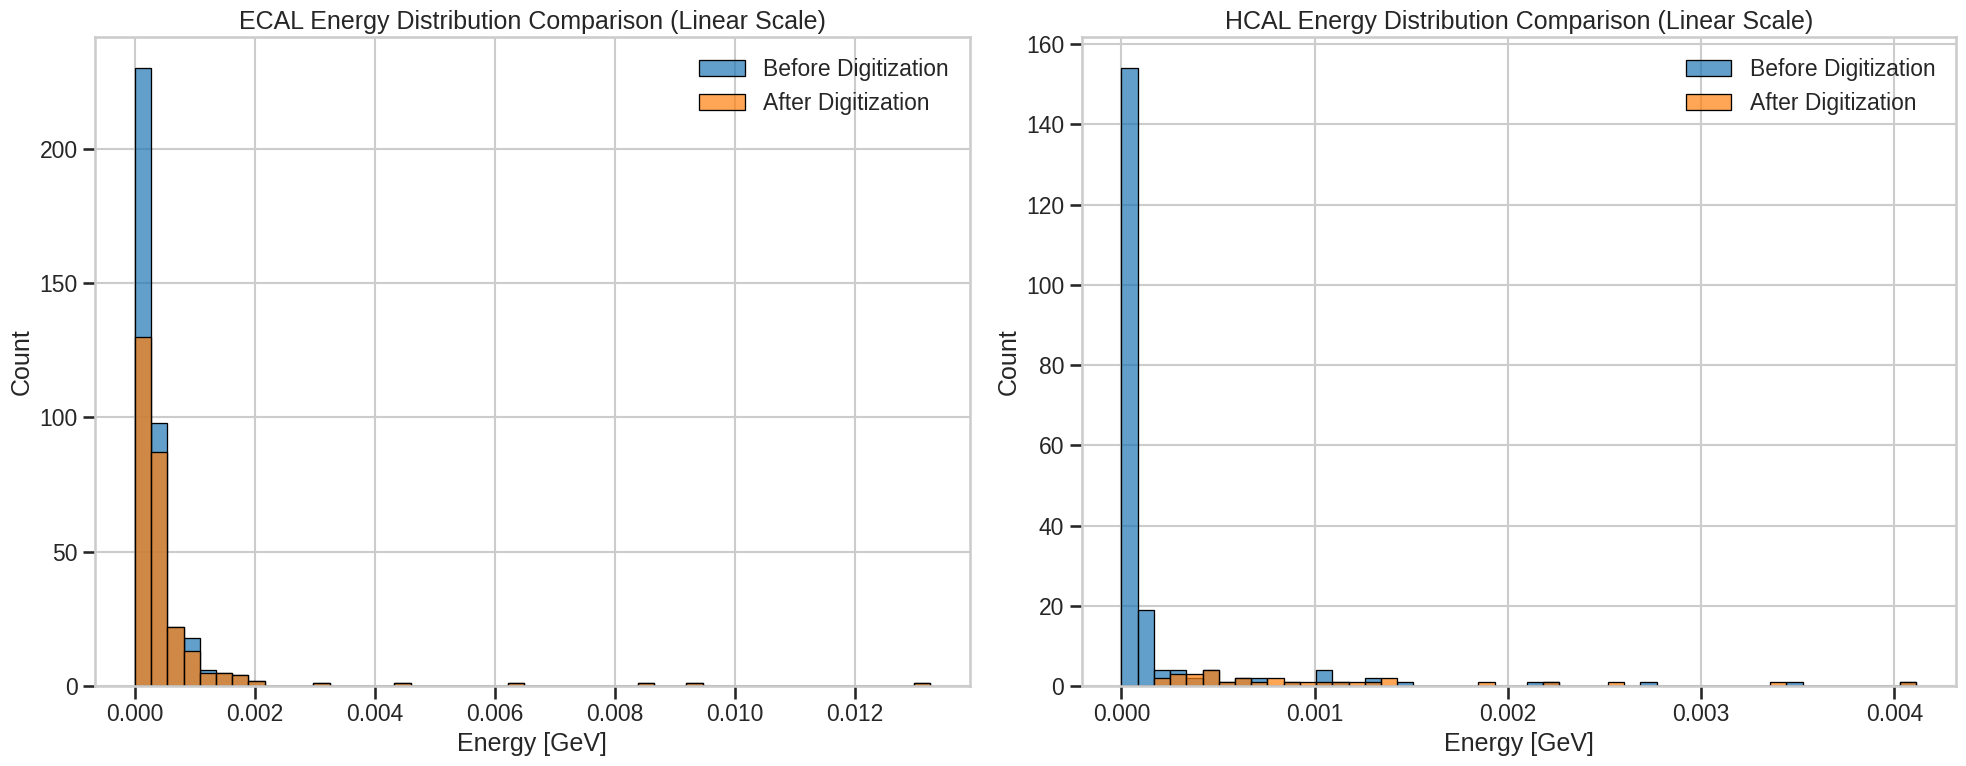

ECAL Statistics:
Original hits:  391
Digitized hits:  274
Fraction of hits kept: 70.08%

Energy statistics:
Original mean energy: 0.000424 GeV
Digitized mean energy: 0.000554 GeV
Original total energy: 0.165672 GeV
Digitized total energy: 0.151770 GeV
Energy retention: 91.61%

HCAL Statistics:
Original hits:  206
Digitized hits:  31
Fraction of hits kept: 15.05%

Energy statistics:
Original mean energy: 0.000177 GeV
Digitized mean energy: 0.001026 GeV
Original total energy: 0.036366 GeV
Digitized total energy: 0.031811 GeV
Energy retention: 87.47%


In [11]:
# Set up the plot style
plt.style.use('seaborn-v0_8-whitegrid')  # Updated style name for newer matplotlib
sns.set_context("talk")

# 1. SEPARATE HISTOGRAMS FOR ECAL AND HCAL
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# ECAL separate histograms
min_energy_ecal = min(ecal_hits['energy'].min(), digi_ecal['energy'].min() if not digi_ecal.empty else 0)
max_energy_ecal = max(ecal_hits['energy'].max(), digi_ecal['energy'].max() if not digi_ecal.empty else 1e-3)
ecal_bins = np.linspace(min_energy_ecal, max_energy_ecal, 50)

sns.histplot(ecal_hits['energy'], bins=ecal_bins, log=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('ECAL Energy Distribution Before Digitization')
axes[0, 0].set_xlabel('Energy [GeV]')
axes[0, 0].set_ylabel('Count')

if not digi_ecal.empty:
    sns.histplot(digi_ecal['energy'], bins=ecal_bins, log=True, ax=axes[0, 1], color='green')
    axes[0, 1].set_title('ECAL Energy Distribution After Digitization')
    axes[0, 1].set_xlabel('Energy [GeV]')
    axes[0, 1].set_ylabel('Count')
else:
    axes[0, 1].text(0.5, 0.5, 'No digitized ECAL hits', ha='center', va='center', fontsize=14)
    axes[0, 1].set_title('ECAL Energy Distribution After Digitization')

# HCAL separate histograms
min_energy_hcal = min(hcal_hits['energy'].min(), digi_hcal['energy'].min() if not digi_hcal.empty else 0)
max_energy_hcal = max(hcal_hits['energy'].max(), digi_hcal['energy'].max() if not digi_hcal.empty else 1e-3)
hcal_bins = np.linspace(min_energy_hcal, max_energy_hcal, 50)

sns.histplot(hcal_hits['energy'], bins=hcal_bins, log=True, ax=axes[1, 0], color='blue')
axes[1, 0].set_title('HCAL Energy Distribution Before Digitization')
axes[1, 0].set_xlabel('Energy [GeV]')
axes[1, 0].set_ylabel('Count')

if not digi_hcal.empty:
    sns.histplot(digi_hcal['energy'], bins=hcal_bins, log=True, ax=axes[1, 1], color='green')
    axes[1, 1].set_title('HCAL Energy Distribution After Digitization')
    axes[1, 1].set_xlabel('Energy [GeV]')
    axes[1, 1].set_ylabel('Count')
else:
    axes[1, 1].text(0.5, 0.5, 'No digitized HCAL hits', ha='center', va='center', fontsize=14)
    axes[1, 1].set_title('HCAL Energy Distribution After Digitization')

plt.tight_layout()
plt.show()

# 2. OVERLAID HISTOGRAMS FOR ECAL AND HCAL
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ECAL overlaid histogram
if not digi_ecal.empty:
    sns.histplot(ecal_hits['energy'], bins=ecal_bins, log=True, alpha=0.7, label='Before Digitization', ax=axes[0])
    sns.histplot(digi_ecal['energy'], bins=ecal_bins, log=True, alpha=0.7, label='After Digitization', ax=axes[0])
    axes[0].set_title('ECAL Energy Distribution Comparison')
    axes[0].set_xlabel('Energy [GeV]')
    axes[0].set_ylabel('Count')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No digitized ECAL hits', ha='center', va='center', fontsize=14)
    axes[0].set_title('ECAL Energy Distribution Comparison')

# HCAL overlaid histogram
if not digi_hcal.empty:
    sns.histplot(hcal_hits['energy'], bins=hcal_bins, log=True, alpha=0.7, label='Before Digitization', ax=axes[1])
    sns.histplot(digi_hcal['energy'], bins=hcal_bins, log=True, alpha=0.7, label='After Digitization', ax=axes[1])
    axes[1].set_title('HCAL Energy Distribution Comparison')
    axes[1].set_xlabel('Energy [GeV]')
    axes[1].set_ylabel('Count')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No digitized HCAL hits', ha='center', va='center', fontsize=14)
    axes[1].set_title('HCAL Energy Distribution Comparison')

plt.tight_layout()
plt.show()

# 3. NON-LOG SCALE OVERLAID HISTOGRAMS
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ECAL overlaid histogram (non-log)
if not digi_ecal.empty:
    sns.histplot(ecal_hits['energy'], bins=ecal_bins, alpha=0.7, label='Before Digitization', ax=axes[0])
    sns.histplot(digi_ecal['energy'], bins=ecal_bins, alpha=0.7, label='After Digitization', ax=axes[0])
    axes[0].set_title('ECAL Energy Distribution Comparison (Linear Scale)')
    axes[0].set_xlabel('Energy [GeV]')
    axes[0].set_ylabel('Count')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No digitized ECAL hits', ha='center', va='center', fontsize=14)
    axes[0].set_title('ECAL Energy Distribution Comparison (Linear Scale)')

# HCAL overlaid histogram (non-log)
if not digi_hcal.empty:
    sns.histplot(hcal_hits['energy'], bins=hcal_bins, alpha=0.7, label='Before Digitization', ax=axes[1])
    sns.histplot(digi_hcal['energy'], bins=hcal_bins, alpha=0.7, label='After Digitization', ax=axes[1])
    axes[1].set_title('HCAL Energy Distribution Comparison (Linear Scale)')
    axes[1].set_xlabel('Energy [GeV]')
    axes[1].set_ylabel('Count')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No digitized HCAL hits', ha='center', va='center', fontsize=14)
    axes[1].set_title('HCAL Energy Distribution Comparison (Linear Scale)')

plt.tight_layout()
plt.show()

# 4. STATISTICS
print("ECAL Statistics:")
print("Original hits: ", len(ecal_hits))
print("Digitized hits: ", len(digi_ecal))
print("Fraction of hits kept: {:.2f}%".format(100 * len(digi_ecal) / len(ecal_hits) if len(ecal_hits) > 0 else 0))
print("\nEnergy statistics:")
print("Original mean energy: {:.6f} GeV".format(ecal_hits['energy'].mean() if not ecal_hits.empty else 0))
print("Digitized mean energy: {:.6f} GeV".format(digi_ecal['energy'].mean() if not digi_ecal.empty else 0))
print("Original total energy: {:.6f} GeV".format(ecal_hits['energy'].sum() if not ecal_hits.empty else 0))
print("Digitized total energy: {:.6f} GeV".format(digi_ecal['energy'].sum() if not digi_ecal.empty else 0))
print("Energy retention: {:.2f}%".format(100 * digi_ecal['energy'].sum() / ecal_hits['energy'].sum() if not ecal_hits.empty and ecal_hits['energy'].sum() > 0 else 0))

print("\nHCAL Statistics:")
print("Original hits: ", len(hcal_hits))
print("Digitized hits: ", len(digi_hcal))
print("Fraction of hits kept: {:.2f}%".format(100 * len(digi_hcal) / len(hcal_hits) if len(hcal_hits) > 0 else 0))
print("\nEnergy statistics:")
print("Original mean energy: {:.6f} GeV".format(hcal_hits['energy'].mean() if not hcal_hits.empty else 0))
print("Digitized mean energy: {:.6f} GeV".format(digi_hcal['energy'].mean() if not digi_hcal.empty else 0))
print("Original total energy: {:.6f} GeV".format(hcal_hits['energy'].sum() if not hcal_hits.empty else 0))
print("Digitized total energy: {:.6f} GeV".format(digi_hcal['energy'].sum() if not digi_hcal.empty else 0))
print("Energy retention: {:.2f}%".format(100 * digi_hcal['energy'].sum() / hcal_hits['energy'].sum() if not hcal_hits.empty and hcal_hits['energy'].sum() > 0 else 0))

### Spatial Distribution


ECAL Ratio Statistics (excluding removed hits and infinite ratios):
Mean ratio: 0.950
Median ratio: 1.000
Min ratio: 0.058
Max ratio: 1.008
Std dev: 0.210
Fraction of bins with ratio < 0.9: 5.26%
Fraction of bins with ratio > 1.1: 0.00%
Fraction of bins removed (ratio=0): 55.81%
Fraction of bins added (ratio=inf): 0.00%


/tmp/ipykernel_23704/1711080826.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


<Figure size 640x480 with 0 Axes>

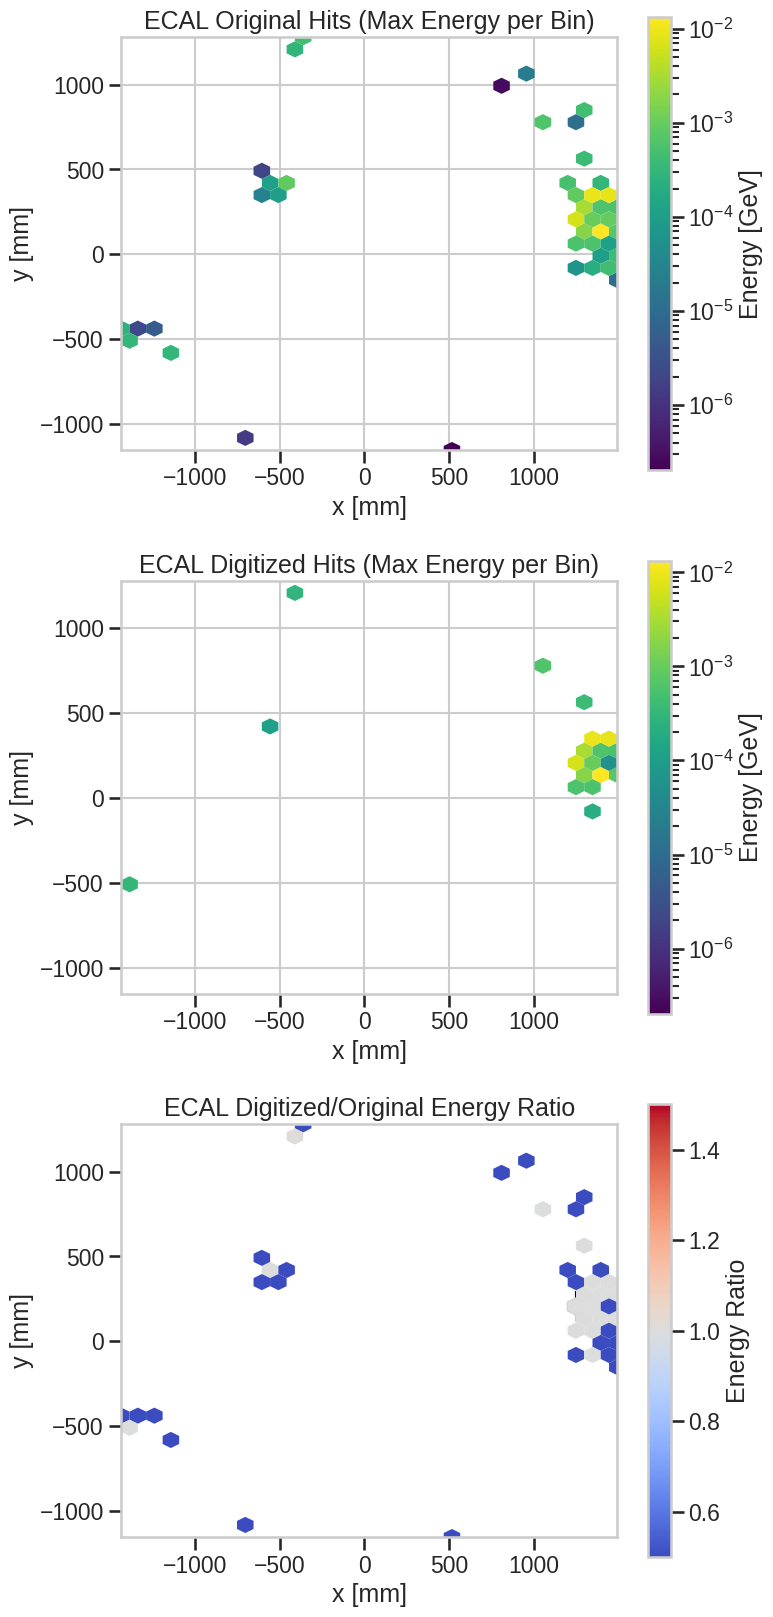


HCAL Ratio Statistics (excluding removed hits and infinite ratios):
Mean ratio: 1.000
Median ratio: 0.995
Min ratio: 0.783
Max ratio: 1.297
Std dev: 0.127
Fraction of bins with ratio < 0.9: 13.33%
Fraction of bins with ratio > 1.1: 20.00%
Fraction of bins removed (ratio=0): 68.09%
Fraction of bins added (ratio=inf): 0.00%


<Figure size 640x480 with 0 Axes>

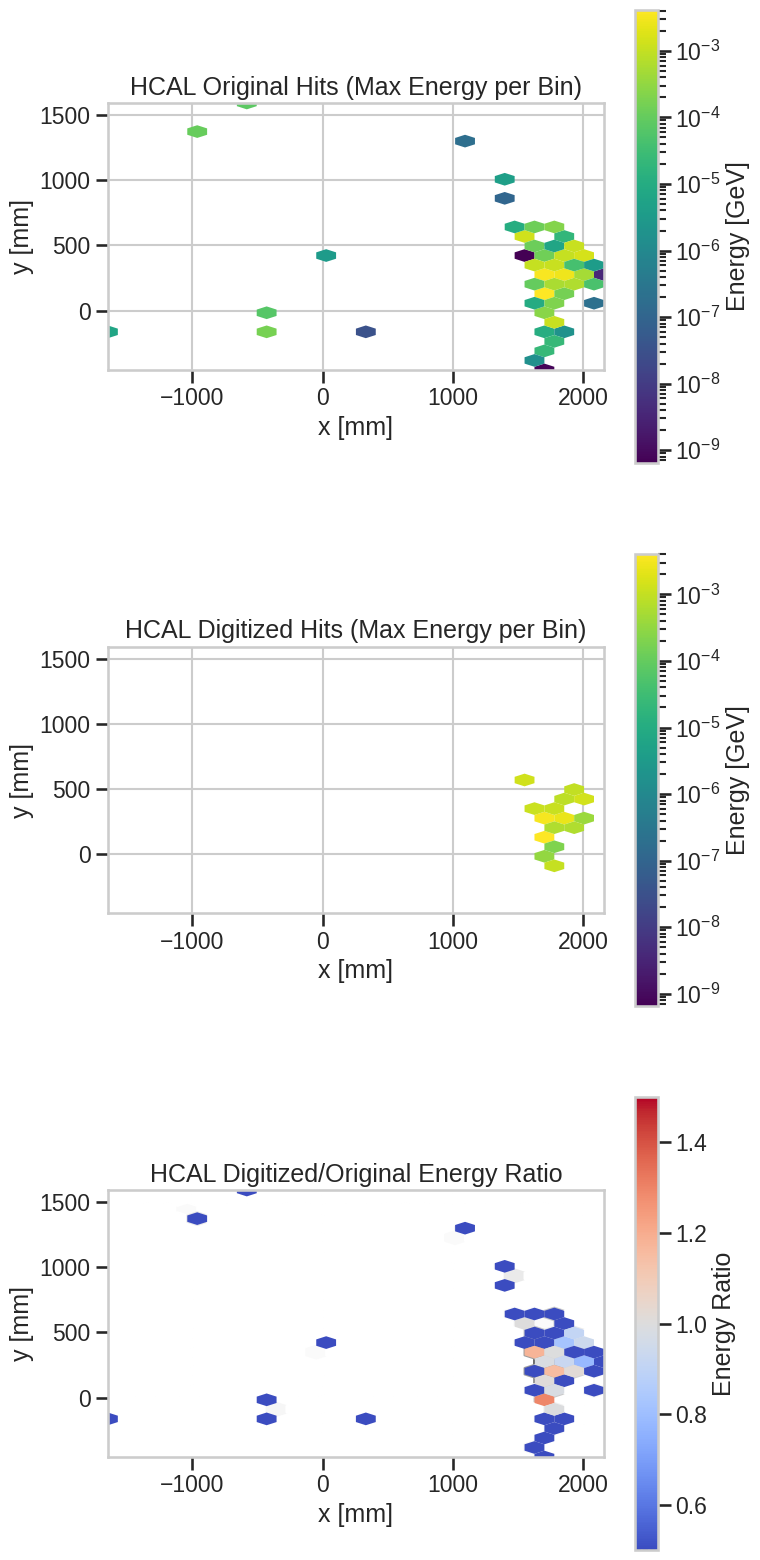

In [16]:

from matplotlib.colors import LogNorm
from matplotlib.collections import PolyCollection
from calorimeter_digitisation import CalorimeterDigitizer, ECAL_COLLECTIONS, HCAL_COLLECTIONS

# Filter ECAL and HCAL hits
ecal_hits = hits_df[hits_df['detector'].isin(ECAL_COLLECTIONS)]
hcal_hits = hits_df[hits_df['detector'].isin(HCAL_COLLECTIONS)]

# Set up the plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")


from matplotlib.colors import LogNorm
from matplotlib.collections import PolyCollection
from calorimeter_digitisation import CalorimeterDigitizer, ECAL_COLLECTIONS, HCAL_COLLECTIONS

# Filter ECAL and HCAL hits
ecal_hits = hits_df[hits_df['detector'].isin(ECAL_COLLECTIONS)]
hcal_hits = hits_df[hits_df['detector'].isin(HCAL_COLLECTIONS)]

# Set up the plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

# Function to create hexagonal binning visualization for either ECAL or HCAL
def create_hexbin_visualization(orig_hits, digi_hits, title_prefix="ECAL", gridsize=30):
    # Create a figure with three subplots
    fig, axes = plt.subplots(3, 1, figsize=(8, 20))
    
    # Define common spatial boundaries for all plots
    if orig_hits.empty or digi_hits.empty:
        print(f"No data for {title_prefix} visualization")
        return None
        
    x_min, x_max = min(orig_hits['x'].min(), digi_hits['x'].min()), max(orig_hits['x'].max(), digi_hits['x'].max())
    y_min, y_max = min(orig_hits['y'].min(), digi_hits['y'].min()), max(orig_hits['y'].max(), digi_hits['y'].max())
    
    # Create a uniform binning scheme that will be used for all plots
    def create_uniform_binning(df1, df2, gridsize=30):
        # Combine data to create a single set of bin centers
        combined_x = np.concatenate([df1['x'].values, df2['x'].values])
        combined_y = np.concatenate([df1['y'].values, df2['y'].values])
        
        # Create a hexbin object to get the bin locations for the combined data
        hb = plt.hexbin(combined_x, combined_y, gridsize=gridsize)
        # Get hexagon paths and centers
        hex_paths = hb.get_paths()[0]  # All hexagons have the same shape
        bin_centers = hb.get_offsets()
        
        plt.close()  # Close the temporary figure
        
        return bin_centers, hex_paths

    def map_data_to_bins(df, bin_centers):
        # Create a dictionary to store max energy per bin
        bin_energy_map = {}
        
        # For each hit, find the closest bin center
        for _, row in df.iterrows():
            # Calculate distances to all bin centers
            distances = np.sqrt((bin_centers[:, 0] - row['x'])**2 + 
                               (bin_centers[:, 1] - row['y'])**2)
            bin_idx = np.argmin(distances)
            bin_key = tuple(bin_centers[bin_idx])
            
            # Update the bin with max energy
            if bin_key in bin_energy_map:
                bin_energy_map[bin_key] = max(bin_energy_map[bin_key], row['energy'])
            else:
                bin_energy_map[bin_key] = row['energy']
        
        return bin_energy_map

    # Create a common set of bin centers for all datasets
    common_bin_centers, hex_path = create_uniform_binning(orig_hits, digi_hits, gridsize=gridsize)
    
    # Map both datasets to the common binning
    orig_map = map_data_to_bins(orig_hits, common_bin_centers)
    digi_map = map_data_to_bins(digi_hits, common_bin_centers)

    # Function to create hexagon patches with colors for each plot
    def create_hex_collection(bin_centers, bin_values, cmap='viridis', vmin=None, vmax=None, norm=None):
        # Create vertex arrays for each hexagon
        verts = []
        colors = []
        
        # Set up the colormap
        if norm is None:
            norm = plt.Normalize(vmin, vmax)
        cmap_obj = plt.cm.get_cmap(cmap)
        
        # For each bin center, create a hexagon and assign color
        for i, center in enumerate(bin_centers):
            key = tuple(center)
            if key in bin_values:
                # Create vertices for this hexagon
                x, y = center
                verts.append(hex_path.vertices + [x, y])
                
                # Assign color based on value
                value = bin_values[key]
                colors.append(cmap_obj(norm(value)))
        
        # Create collection of hexagons
        collection = PolyCollection(verts, facecolors=colors, edgecolors='none')
        return collection

    # Calculate vmin, vmax for consistent color scale
    all_energies = list(orig_map.values()) + list(digi_map.values())
    vmin, vmax = min(all_energies), max(all_energies)
    norm = LogNorm(vmin=vmin, vmax=vmax)

    # Create and add original hits hexagons
    orig_hexes = create_hex_collection(common_bin_centers, orig_map, 
                                      cmap='viridis', norm=norm)
    axes[0].add_collection(orig_hexes)
    axes[0].set_title(f'{title_prefix} Original Hits (Max Energy per Bin)')
    axes[0].set_xlabel('x [mm]')
    axes[0].set_ylabel('y [mm]')
    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_min, y_max)
    axes[0].set_aspect('equal')

    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    cbar1 = fig.colorbar(sm, ax=axes[0])
    cbar1.set_label('Energy [GeV]')
    # display(fig)

    # Digitized hits plot with common binning
    digi_hexes = create_hex_collection(common_bin_centers, digi_map, 
                                      cmap='viridis', norm=norm)
    axes[1].add_collection(digi_hexes)
    axes[1].set_title(f'{title_prefix} Digitized Hits (Max Energy per Bin)')
    axes[1].set_xlabel('x [mm]')
    axes[1].set_ylabel('y [mm]')
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)
    axes[1].set_aspect('equal')
    # display(fig)

    # Create colorbar
    cbar2 = fig.colorbar(sm, ax=axes[1])
    cbar2.set_label('Energy [GeV]')

    # Calculate ratios for the third plot
    ratio_map = {}

    # Process all bins that appear in either dataset
    for center in common_bin_centers:
        bin_key = tuple(center)
        
        if bin_key in orig_map and bin_key in digi_map:
            # Both datasets have this bin
            if orig_map[bin_key] > 0:
                ratio_map[bin_key] = digi_map[bin_key] / orig_map[bin_key]
            else:
                ratio_map[bin_key] = 1.0  # Default to 1.0 if original energy is zero
        elif bin_key in orig_map:
            # Only in original - ratio is 0
            ratio_map[bin_key] = 0.0
        elif bin_key in digi_map:
            # Only in digitized - could use inf or a large value
            ratio_map[bin_key] = np.inf

    # Create ratio hexagons - filter out infinity values for display
    ratio_map_finite = {k: v for k, v in ratio_map.items() if np.isfinite(v)}
    ratio_norm = plt.Normalize(0.5, 1.5)  # Adjust range for ratio visualization
    ratio_hexes = create_hex_collection(common_bin_centers, ratio_map_finite, 
                                       cmap='coolwarm', norm=ratio_norm)
    axes[2].add_collection(ratio_hexes)
    axes[2].set_title(f'{title_prefix} Digitized/Original Energy Ratio')
    axes[2].set_xlabel('x [mm]')
    axes[2].set_ylabel('y [mm]')
    axes[2].set_xlim(x_min, x_max)
    axes[2].set_ylim(y_min, y_max)
    axes[2].set_aspect('equal')
    # display(fig)

    # Create colorbar for ratio
    sm_ratio = plt.cm.ScalarMappable(cmap='coolwarm', norm=ratio_norm)
    sm_ratio.set_array([])
    cbar3 = fig.colorbar(sm_ratio, ax=axes[2])
    cbar3.set_label('Energy Ratio')

    # Add a horizontal line at ratio=1.0 in the colorbar legend
    cbar3.ax.axhline(y=0.5, color='k', linestyle='--', linewidth=1)

    plt.tight_layout()
    
    # Extract statistics values for reporting
    ratio_values = list(ratio_map.values())
    ratio_array = np.array(ratio_values)
    valid_ratios = ratio_array[(ratio_array > 0) & np.isfinite(ratio_array)]  # Exclude zeros and inf

    print(f"\n{title_prefix} Ratio Statistics (excluding removed hits and infinite ratios):")
    if len(valid_ratios) > 0:
        print(f"Mean ratio: {valid_ratios.mean():.3f}")
        print(f"Median ratio: {np.median(valid_ratios):.3f}")
        print(f"Min ratio: {valid_ratios.min():.3f}")
        print(f"Max ratio: {valid_ratios.max():.3f}")
        print(f"Std dev: {valid_ratios.std():.3f}")
        print(f"Fraction of bins with ratio < 0.9: {np.sum(valid_ratios < 0.9) / len(valid_ratios):.2%}")
        print(f"Fraction of bins with ratio > 1.1: {np.sum(valid_ratios > 1.1) / len(valid_ratios):.2%}")
    else:
        print("No valid ratio values found (valid_ratios array is empty)")

    # Calculate coverage statistics
    if len(ratio_array) > 0:
        print(f"Fraction of bins removed (ratio=0): {np.sum(ratio_array == 0) / len(ratio_array):.2%}")
        print(f"Fraction of bins added (ratio=inf): {np.sum(np.isinf(ratio_array)) / len(ratio_array):.2%}")
    
    return fig

# Create ECAL visualization (using 30 bins in each dimension)
ecal_fig = create_hexbin_visualization(ecal_hits, digi_ecal, title_prefix="ECAL", gridsize=30)
if ecal_fig:
    plt.figure(ecal_fig.number)
    plt.show()
    display(ecal_fig)

# Create HCAL visualization (using 25 bins because HCAL typically has larger cells)
hcal_fig = create_hexbin_visualization(hcal_hits, digi_hcal, title_prefix="HCAL", gridsize=25)
if hcal_fig:
    plt.figure(hcal_fig.number)
    plt.show()
    display(hcal_fig)

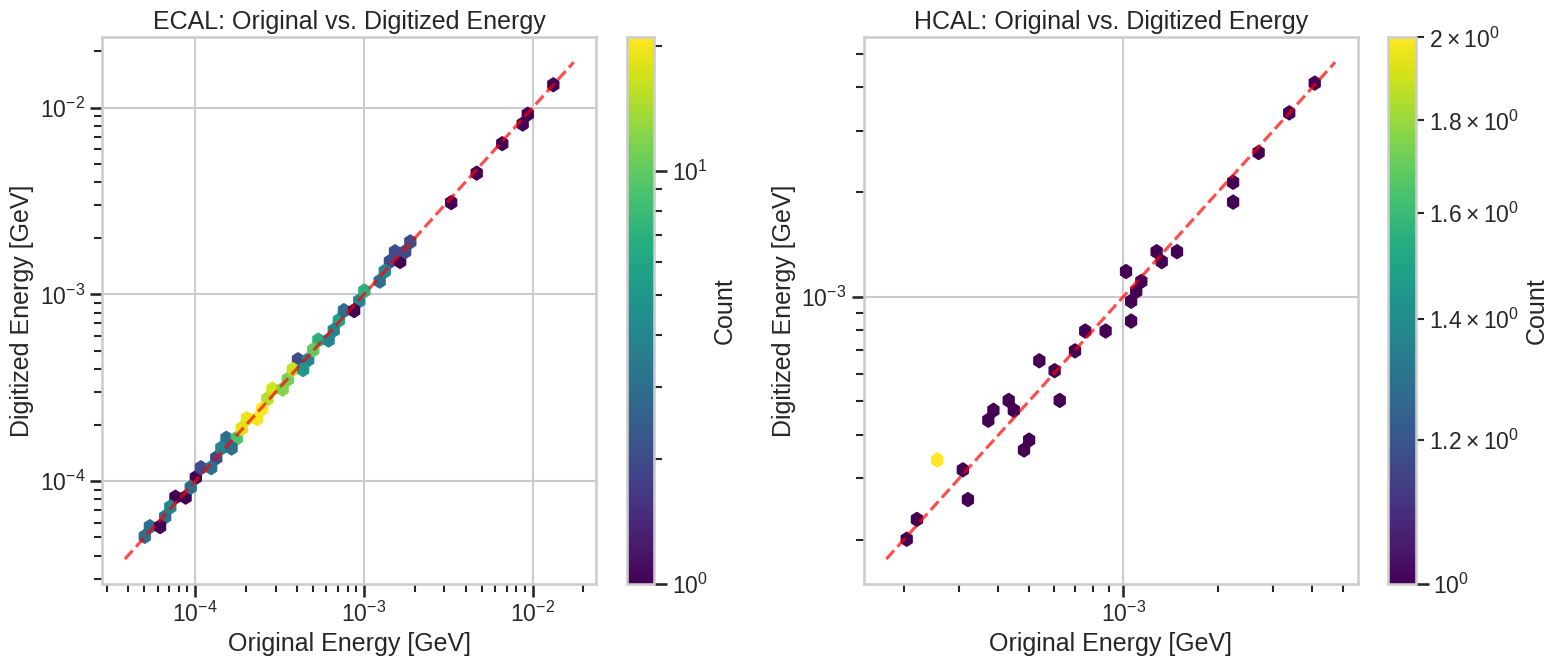

In [14]:

# Now create an alternative visualization to specifically highlight the SiPM effect
# This will be a 2D histogram showing the correlation between original and digitized energies
# separately for ECAL and HCAL
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Create merged dataframes to correlate original and digitized hits
def create_correlation_df(orig_hits, digi_hits):
    # Create a merged dataframe by matching the closest hits in spatial coordinates
    if orig_hits.empty or digi_hits.empty:
        return pd.DataFrame()
        
    matched_data = []
    # For each digitized hit, find the closest original hit
    for _, digi_row in digi_hits.iterrows():
        distances = np.sqrt((orig_hits['x'] - digi_row['x'])**2 + 
                           (orig_hits['y'] - digi_row['y'])**2 + 
                           (orig_hits['z'] - digi_row['z'])**2)
        if len(distances) > 0:
            closest_idx = distances.argmin()
            orig_row = orig_hits.iloc[closest_idx]
            
            # Only include pairs that are reasonably close (within 1mm)
            if distances.min() < 1.0:
                matched_data.append({
                    'orig_energy': orig_row['energy'],
                    'digi_energy': digi_row['energy'],
                    'x': digi_row['x'],
                    'y': digi_row['y'],
                    'z': digi_row['z'],
                    'detector': digi_row['detector']
                })
    
    return pd.DataFrame(matched_data)

# Create correlation dataframes
ecal_corr = create_correlation_df(ecal_hits, digi_ecal)
hcal_corr = create_correlation_df(hcal_hits, digi_hcal)

# Create 2D histogram for ECAL
if not ecal_corr.empty:
    h1 = axes[0].hexbin(
        ecal_corr['orig_energy'], ecal_corr['digi_energy'],
        gridsize=40, bins='log', cmap='viridis',
        mincnt=1, xscale='log', yscale='log'
    )
    axes[0].set_xlabel('Original Energy [GeV]')
    axes[0].set_ylabel('Digitized Energy [GeV]')
    axes[0].set_title('ECAL: Original vs. Digitized Energy')
    
    # Add diagonal reference line
    xlim = axes[0].get_xlim()
    ylim = axes[0].get_ylim()
    minval = max(xlim[0], ylim[0])
    maxval = min(xlim[1], ylim[1])
    axes[0].plot([minval, maxval], [minval, maxval], 'r--', alpha=0.7)
    
    fig.colorbar(h1, ax=axes[0], label='Count')
else:
    axes[0].text(0.5, 0.5, 'No ECAL correlation data', 
                 ha='center', va='center', fontsize=14, transform=axes[0].transAxes)
    axes[0].set_title('ECAL: Original vs. Digitized Energy')

# Create 2D histogram for HCAL
if not hcal_corr.empty:
    h2 = axes[1].hexbin(
        hcal_corr['orig_energy'], hcal_corr['digi_energy'],
        gridsize=40, bins='log', cmap='viridis',
        mincnt=1, xscale='log', yscale='log'
    )
    axes[1].set_xlabel('Original Energy [GeV]')
    axes[1].set_ylabel('Digitized Energy [GeV]')
    axes[1].set_title('HCAL: Original vs. Digitized Energy')
    
    # Add diagonal reference line
    xlim = axes[1].get_xlim()
    ylim = axes[1].get_ylim()
    minval = max(xlim[0], ylim[0])
    maxval = min(xlim[1], ylim[1])
    axes[1].plot([minval, maxval], [minval, maxval], 'r--', alpha=0.7)
    
    fig.colorbar(h2, ax=axes[1], label='Count')
else:
    axes[1].text(0.5, 0.5, 'No HCAL correlation data', 
                 ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('HCAL: Original vs. Digitized Energy')

plt.tight_layout()
plt.show()

## Effect of Binomial Sampling and Low Energy Hits

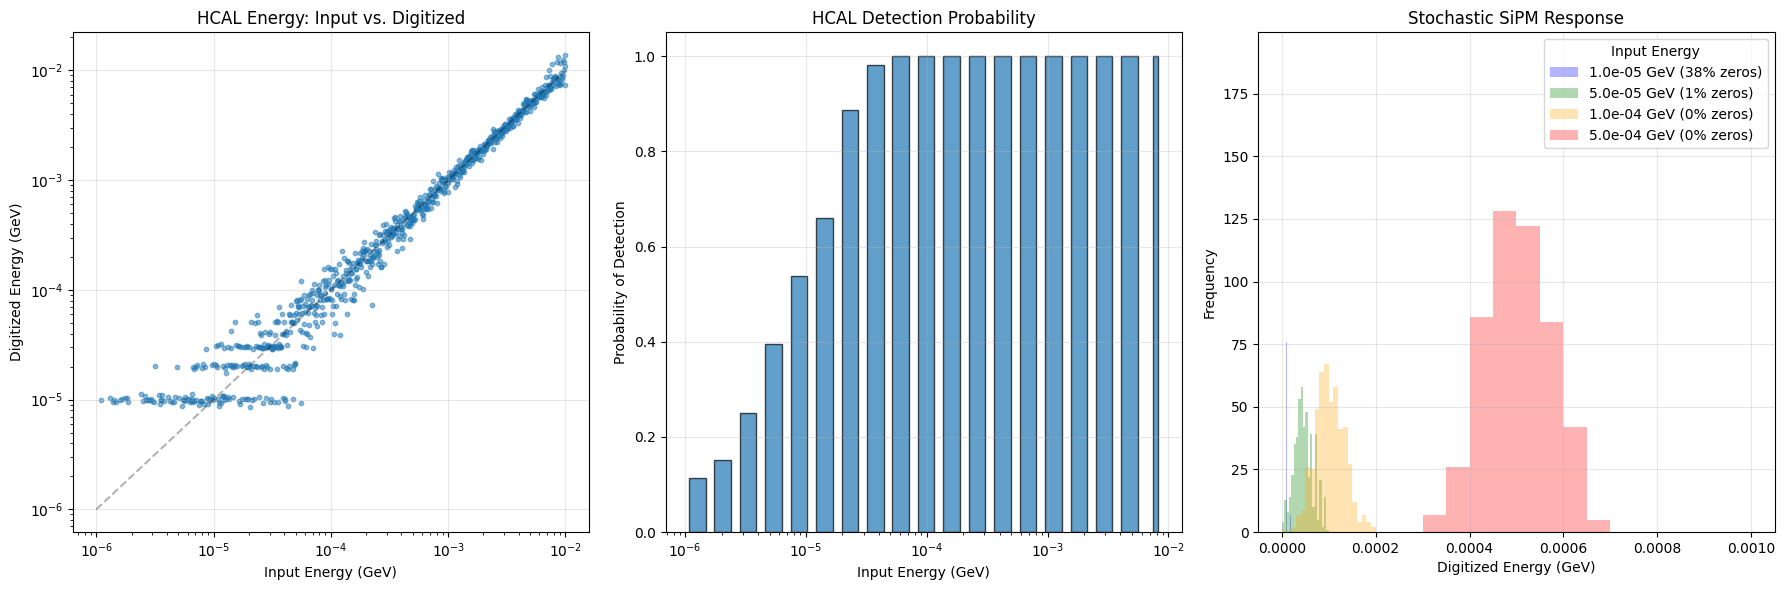

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm
from hcal_digitisation import HcalDigitizer

# Create a test dataset with a wide range of energies
# Use log spacing to ensure good coverage of low energies
energies = np.logspace(-6, -2, 1000)  # From 1e-6 to 1e-2 GeV
test_data = pd.DataFrame({
    'energy': energies,
    'time': np.zeros_like(energies),
    'x': np.zeros_like(energies),
    'y': np.zeros_like(energies),
    'detector': ['HCalBarrelCollection'] * len(energies)
})

# Configure the HCAL digitizer
hcal_config = {
    "hcal_PPD_pe_per_mip": 10,  # Photoelectrons per MIP
    "hcal_PPD_n_pixels": 400,   # Number of pixels in SiPM
    "calibHcalMip": 1.0e-4,     # MIP calibration factor
    "thresholdHcal": 0.0,       # Set to zero to see pure SiPM effects
    "hcal_elec_noise": 0.0      # No electronics noise for clarity
}

# Initialize the digitizer
digitizer = HcalDigitizer(hcal_config)

# Function to digitize a single energy value multiple times 
# to show the stochastic nature
def digitize_multiple(energy, n_samples=100):
    results = []
    for _ in range(n_samples):
        row = test_data.iloc[0].copy()
        row['energy'] = energy
        digi_energy, _ = digitizer.digitise_hit(
            energy, 0, (0, 0), True, (0, 0, 0)
        )
        results.append(digi_energy)
    return results

# Process each energy through the digitizer once
digitized_energies = []
for energy in energies:
    digi_energy, _ = digitizer.digitise_hit(
        energy, 0, (0, 0), True, (0, 0, 0)
    )
    digitized_energies.append(digi_energy)

# Create a 2D visualization - 3 panels

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Scatter plot of input vs output energy
axes[0].scatter(energies, digitized_energies, alpha=0.5, s=10)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Input Energy (GeV)')
axes[0].set_ylabel('Digitized Energy (GeV)')
axes[0].set_title('HCAL Energy: Input vs. Digitized')
axes[0].plot([min(energies), max(energies)], [min(energies), max(energies)], 'k--', alpha=0.3)
axes[0].grid(True, alpha=0.3)

# Panel 2: Probability of detection vs. energy
# Group energies into bins and compute fraction of non-zero outputs
energy_bins = np.logspace(-6, -2, 20)
detection_prob = []

for i in range(len(energy_bins)-1):
    e_min, e_max = energy_bins[i], energy_bins[i+1]
    bin_energies = [e for e, d in zip(energies, digitized_energies) 
                   if e_min <= e < e_max]
    bin_digitized = [d for e, d in zip(energies, digitized_energies) 
                    if e_min <= e < e_max]
    
    if bin_energies:
        prob = sum(d > 0 for d in bin_digitized) / len(bin_digitized)
        detection_prob.append((np.sqrt(e_min * e_max), prob))

e_vals, p_vals = zip(*detection_prob) if detection_prob else ([], [])
# Create a bar histogram with non-overlapping bars
# Calculate width as a fraction of the bin center to prevent overlap in log scale
width_factors = np.array([(e_vals[i+1] - e_vals[i])/2 for i in range(len(e_vals)-1)] + [e_vals[-1] * 0.1])
axes[1].bar(e_vals, p_vals, width=width_factors, alpha=0.7, edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_xlabel('Input Energy (GeV)')
axes[1].set_ylabel('Probability of Detection')
axes[1].set_title('HCAL Detection Probability')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

# Panel 3: Stochastic response for selected energies
selected_energies = [1e-5, 5e-5, 1e-4, 5e-4]
colors = ['blue', 'green', 'orange', 'red']

for energy, color in zip(selected_energies, colors):
    digi_results = digitize_multiple(energy, n_samples=500)
    # Compute histogram but include zeros
    hist, bin_edges = np.histogram(digi_results, bins=20, range=(0, energy*2))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Get percentage of zeros for labeling
    zero_pct = sum(r == 0 for r in digi_results) / len(digi_results) * 100
    
    axes[2].stairs(hist, bin_edges, fill=True, alpha=0.3, color=color, 
             label=f'{energy:.1e} GeV ({zero_pct:.0f}% zeros)')

axes[2].set_xlabel('Digitized Energy (GeV)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Stochastic SiPM Response')
axes[2].legend(title="Input Energy")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()